<a href="https://colab.research.google.com/github/ardiyoga/ardiyoga/blob/main/LinearRegressionForPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.linear_model import LinearRegression

In [ ]:
linear_model = LinearRegression(fit_intercept=false).fit

In [2]:
!wget --no-check-certificate https://raw.githubusercontent.com/inixrust/datasets/main/housing.csv

--2024-09-03 06:29:26--  https://raw.githubusercontent.com/inixrust/datasets/main/housing.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1423529 (1.4M) [text/plain]
Saving to: ‘housing.csv’

housing.csv         100%[===================>]   1.36M  7.28MB/s    in 0.2s    

2024-09-03 06:29:27 (7.28 MB/s) - ‘housing.csv’ saved [1423529/1423529]



In [34]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn  as sns

In [4]:
housing_data = pd.read_csv('/content/housing.csv')

In [5]:
housing_data.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
9700,-121.62,36.67,31.0,2697.0,690.0,2220.0,665.0,2.5329,135200.0,<1H OCEAN
7005,-118.06,33.97,37.0,1645.0,308.0,1077.0,320.0,4.3203,159200.0,<1H OCEAN
2769,-115.98,33.32,8.0,240.0,46.0,63.0,24.0,1.4688,53800.0,INLAND
3598,-118.50,34.25,32.0,2411.0,380.0,1040.0,344.0,6.1550,257300.0,<1H OCEAN
12663,-121.46,38.49,15.0,10211.0,1995.0,5656.0,1752.0,2.5750,107900.0,INLAND


In [6]:
housing_data = housing_data.dropna()

In [7]:
housing_data.shape

(20433, 10)

In [8]:
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


from matplotlib import pyplot as plt
_df_0['longitude'].plot(kind='hist', bins=20, title='longitude')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['latitude'].plot(kind='hist', bins=20, title='latitude')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['housing_median_age'].plot(kind='hist', bins=20, title='housing_median_age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['total_rooms'].plot(kind='hist', bins=20, title='total_rooms')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_7.plot(kind='scatter', x='total_rooms', y='total_bedrooms', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_8['longitude'].plot(kind='line', figsize=(8, 4), title='longitude')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_9['latitude'].plot(kind='line', figsize=(8, 4), title='latitude')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['housing_median_age'].plot(kind='line', figsize=(8, 4), title='housing_median_age')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_11['total_rooms'].plot(kind='line', figsize=(8, 4), title='total_rooms')
plt.gca().spines[['top', 'right']].set_visible(False)

In [9]:
housing_data.loc[housing_data['median_house_value'] == 500001].count()

,0
longitude,958
latitude,958
housing_median_age,958
total_rooms,958
total_bedrooms,958
population,958
households,958
median_income,958
median_house_value,958
ocean_proximity,958


In [10]:
housing_data = housing_data.drop(housing_data.loc[housing_data['median_house_value'] == 500001].index)

In [11]:
housing_data.shape

(19475, 10)

In [12]:
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [13]:
housing_data['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [14]:
housing_data = pd.get_dummies(housing_data, columns=['ocean_proximity'])

In [15]:
housing_data.shape

(19475, 14)

In [16]:
housing_data.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14576,-117.20,32.83,35.0,1377.0,350.0,792.0,313.0,2.8472,161400.0,False,False,False,False,True
7620,-118.25,33.84,19.0,1731.0,420.0,1032.0,364.0,3.8125,208100.0,True,False,False,False,False
16474,-121.25,38.14,16.0,1174.0,242.0,464.0,261.0,2.3000,133300.0,False,True,False,False,False
19059,-122.49,38.22,33.0,1486.0,290.0,781.0,274.0,3.5647,251800.0,False,False,False,True,False
11981,-117.50,33.98,21.0,2394.0,416.0,1291.0,381.0,4.2099,138700.0,False,True,False,False,False


In [17]:
X = housing_data.drop('median_house_value', axis=1)
Y =housing_data['median_house_value']

In [18]:
X.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [19]:
from sklearn.model_selection import train_test_split

x-train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2)

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (<ipython-input-19-f0156113e9d7>, line 3)

In [20]:
from sklearn.model_selection import train_test_split

x-train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (<ipython-input-20-7f1f7d740bef>, line 3)

In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2)

In [22]:
x_train.shape, x_test.shape

((15580, 13), (3895, 13))

In [23]:
y_train.shape, y_test.shape

((15580,), (3895,))

In [24]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression(fit_intercept=False).fit(x_train, y_train)

In [25]:
print("Training_score : " , linear_model.score(x_train, y_train))

Training_score :  0.6155046621501641


In [26]:
predictors = x_train.columns

predictors

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [28]:
coef = pd.Series(linear_model.coef_, predictors).sort_values()

print(coef)

ocean_proximity_INLAND       -2.149090e+06
ocean_proximity_NEAR BAY     -2.119015e+06
ocean_proximity_<1H OCEAN    -2.110791e+06
ocean_proximity_NEAR OCEAN   -2.107334e+06
ocean_proximity_ISLAND       -2.000756e+06
longitude                    -2.465574e+04
latitude                     -2.273235e+04
population                   -2.957360e+01
total_rooms                  -7.234711e+00
households                    4.554483e+01
total_bedrooms                8.958803e+01
housing_median_age            9.644425e+02
median_income                 3.867444e+04
dtype: float64


In [29]:
y_pred = linear_model.predict(x_test)

In [30]:
df_pred_actual = pd.DataFrame({'predicted': y_pred, 'actual': y_test})

df_pred_actual.head(10)

,predicted,actual
12867,155166.727670,98600.0
7092,270556.233029,185300.0
9328,234834.123087,290800.0
15047,280234.331684,296400.0
15503,332001.695616,340300.0
3241,79624.624597,42100.0
938,213954.498514,178200.0
11556,245592.642540,248100.0
11588,288764.770766,207400.0
2469,58362.132012,69400.0


In [31]:
from sklearn.metrics import r2_score

print("Testing_score : ", r2_score(y_test, y_pred))

Testing_score :  0.6012523618758548


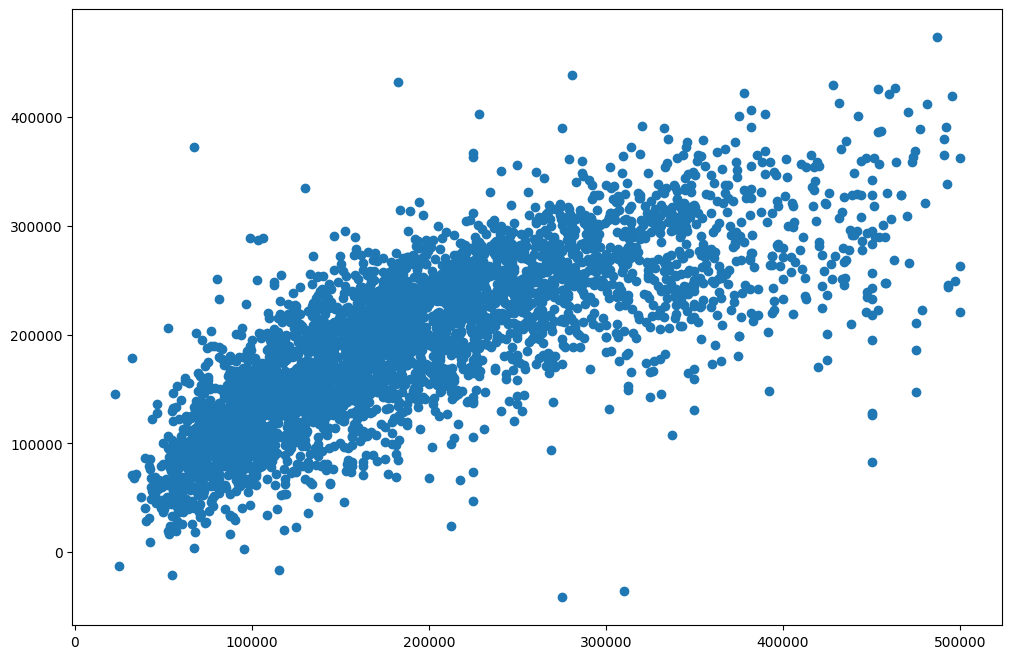

In [35]:
fig, ax = plt.subplots(figsize=(12, 8))

plt.scatter(y_test, y_pred)
plt.show()

In [36]:
df_pred_actual_sample = df_pred_actual.sample(100)
df_pred_actual_sample = df_pred_actual_sample.reset_index()

In [37]:
df_pred_actual_sample.head()

,index,predicted,actual
0,14499,206779.333491,180100.0
1,17925,314590.693934,307400.0
2,3498,203299.583168,185800.0
3,1449,209998.379261,144900.0
4,5626,197468.147327,160100.0


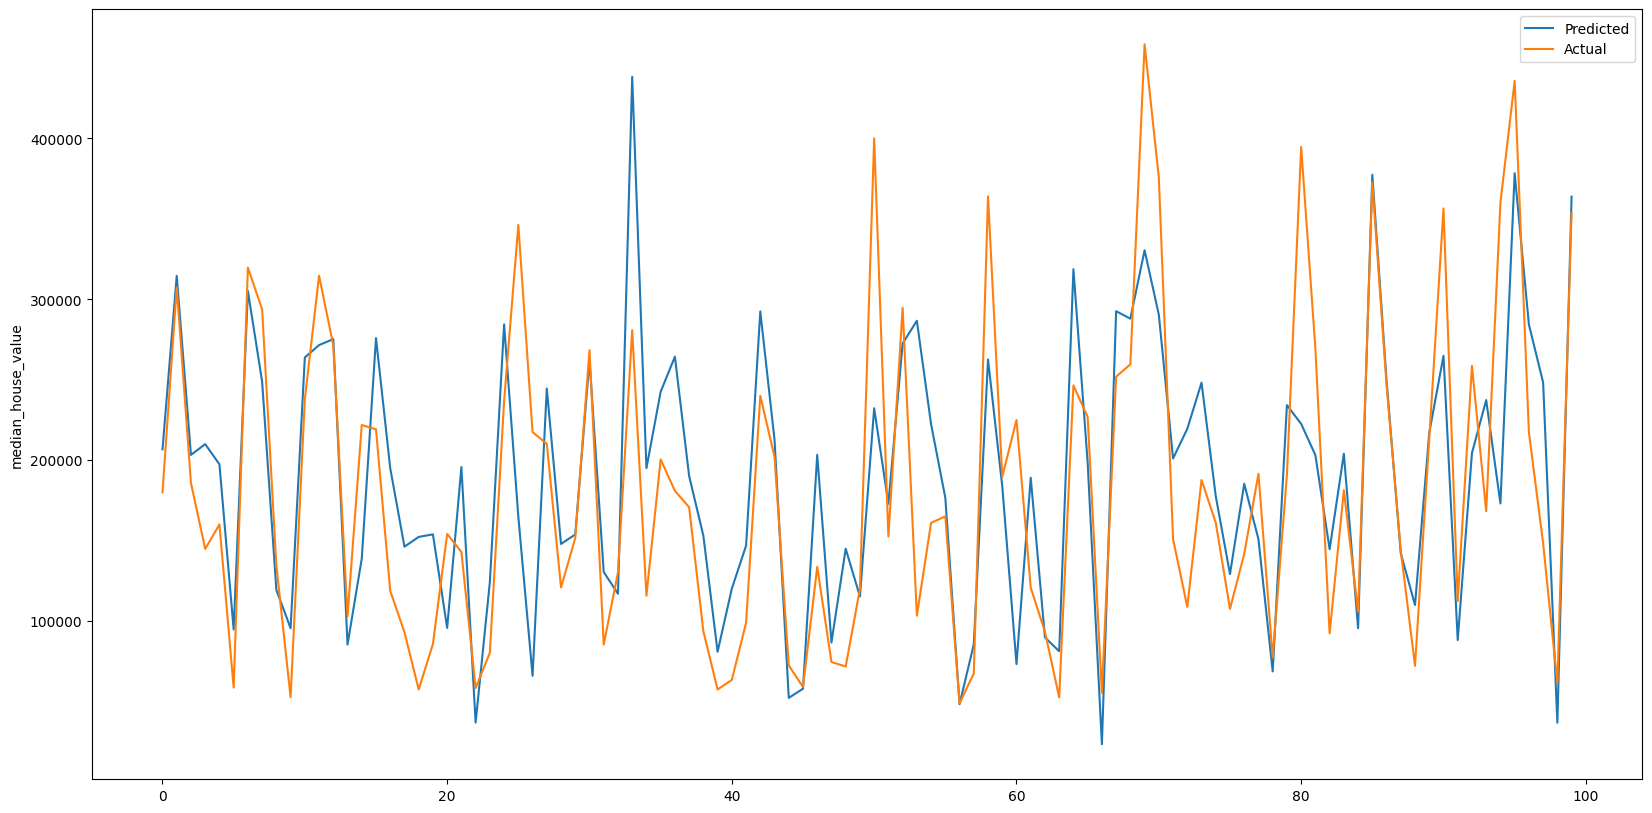

In [38]:
plt.figure(figsize = (20,10))

plt.plot(df_pred_actual_sample['predicted'], label='Predicted')
plt.plot(df_pred_actual_sample['actual'], label='Actual')

plt.ylabel('median_house_value')

plt.legend()
plt.show()